# Week 4 — Day 2: SQL Window Functions

## Concepts Covered
- ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...)
- Running totals with SUM() OVER (ORDER BY ...)
- Replicating window functions in Pandas using cumsum()
- LeetCode SQL #175 and #176

---

## Task 1 — Top 3 fare payers per class using ROW_NUMBER

Used ROW_NUMBER() partitioned by Pclass and ordered by Fare DESC.
Wrapped in a subquery to filter rank <= 3.

**Key insight:** When multiple passengers pay identical fares, ROW_NUMBER assigns
arbitrary ranks 1,2,3 — unlike RANK() which would give all three rank 1.
The Sage family occupied all 3 top spots in 3rd class despite paying nearly
as much as 2nd class passengers.

---

## Task 2 — Cumulative fare using SUM() OVER

Running total of fare collected, ordered by PassengerId.
Each row shows total fare collected from passenger 1 up to that point.

**Common mistake:** Ordering by Fare DESC inside the window gives a
descending cumulative — not a true running total. Must use same ORDER BY
as the main query (PassengerId).

---

## Task 3 — Pandas vs SQL verification

Replicated SQL running total using:
- df.sort_values('PassengerId')
- df['Fare'].cumsum()

Both SQL and Pandas gave identical results row-by-row ✅

| PassengerId | Fare | cumulative_fare |
|-------------|------|-----------------|
| 1 | 7.25 | 7.25 |
| 2 | 71.28 | 78.53 |
| 3 | 7.93 | 86.46 |

---

## Task 4 — LeetCode SQL

### #175 — Combine Two Tables
```sql
SELECT Person.firstName, Person.lastName, Address.city, Address.state
FROM Person
LEFT JOIN Address ON Person.personId = Address.personId
```
Used LEFT JOIN because a person may not have an address entry.
INNER JOIN would silently drop those people — wrong answer.

### #176 — Second Highest Salary
```sql
SELECT MAX(salary) AS SecondHighestSalary
FROM Employee
WHERE salary < (
    SELECT MAX(salary)
    FROM Employee
)
```
Subquery finds the maximum salary. Outer query finds the maximum
of everything strictly below it — giving the second highest.

---

## Key Takeaways
- Window functions don't reduce row count unlike GROUP BY
- PARTITION BY is like groupby, ORDER BY inside OVER controls the window frame
- Always verify SQL results against Pandas — if they match, both are correct
- ROW_NUMBER, RANK, SUM OVER are the 3 most common interview window patterns

# Set up SQLite with Titanic:

In [1]:
import sqlite3
import pandas as pd
import numpy as np

# load Titanic
df = pd.read_csv('train.csv')

# create SQLite database in memory
conn = sqlite3.connect(':memory:')

# load DataFrame into SQLite table
df.to_sql('titanic', conn, index=False, if_exists='replace')

print("Database created successfully")
print(f"Rows loaded: {pd.read_sql('SELECT COUNT(*) as total FROM titanic', conn).iloc[0,0]}")

Database created successfully
Rows loaded: 891


# Rank passenger acc to fare and rank top 3 passenger for each department

In [2]:
q = pd.read_sql("""
SELECT * FROM (
    SELECT PassengerId, Name, Pclass, Fare,
       ROW_NUMBER() OVER (PARTITION BY Pclass ORDER BY Fare DESC) as rank
    FROM titanic )
WHERE rank <= 3
""", conn)
print(q)

   PassengerId                                Name  Pclass      Fare  rank
0          259                    Ward, Miss. Anna       1  512.3292     1
1          680  Cardeza, Mr. Thomas Drake Martinez       1  512.3292     2
2          738              Lesurer, Mr. Gustave J       1  512.3292     3
3           73                Hood, Mr. Ambrose Jr       2   73.5000     1
4          121         Hickman, Mr. Stanley George       2   73.5000     2
5          386           Davies, Mr. Charles Henry       2   73.5000     3
6          160          Sage, Master. Thomas Henry       3   69.5500     1
7          181        Sage, Miss. Constance Gladys       3   69.5500     2
8          202                 Sage, Mr. Frederick       3   69.5500     3


# cumulative passenger count and cumulative fare
# ordered by PassengerId
# using SUM() OVER (ORDER BY PassengerId)

In [3]:
q = pd.read_sql("""
    SELECT PassengerId, Name, Pclass, Fare,
       COUNT(*) OVER (ORDER BY PassengerId ) as cumulative_passengers,
       SUM(Fare) OVER (ORDER BY PassengerId) as cummulative_fare
    FROM titanic 
""", conn)
print(q)

     PassengerId                                               Name  Pclass  \
0              1                            Braund, Mr. Owen Harris       3   
1              2  Cumings, Mrs. John Bradley (Florence Briggs Th...       1   
2              3                             Heikkinen, Miss. Laina       3   
3              4       Futrelle, Mrs. Jacques Heath (Lily May Peel)       1   
4              5                           Allen, Mr. William Henry       3   
..           ...                                                ...     ...   
886          887                              Montvila, Rev. Juozas       2   
887          888                       Graham, Miss. Margaret Edith       1   
888          889           Johnston, Miss. Catherine Helen "Carrie"       3   
889          890                              Behr, Mr. Karl Howell       1   
890          891                                Dooley, Mr. Patrick       3   

        Fare  cumulative_passengers  cummulative_fa

# Plot the graph of cummulative fare and fare

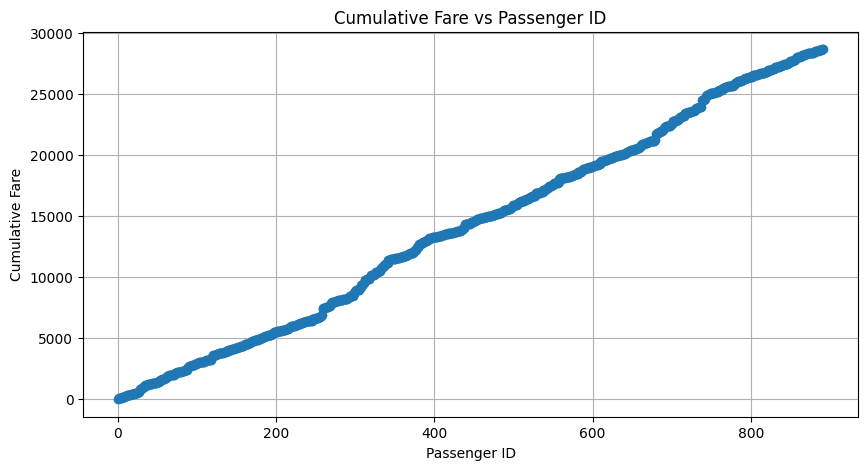

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

q = pd.read_sql("""
    SELECT PassengerId,
           Fare,
           SUM(Fare) OVER (ORDER BY PassengerId) AS cumulative_fare
    FROM titanic
""", conn)

plt.figure(figsize=(10,5))
plt.plot(q["PassengerId"], q["cumulative_fare"], marker="o")

plt.xlabel("Passenger ID")
plt.ylabel("Cumulative Fare")
plt.title("Cumulative Fare vs Passenger ID")
plt.grid(True)

plt.show()

# Replicate this in Pandas without SQL:

# Sort by PassengerId first, then:
# cumulative_passengers → just a count of rows as you go
# cumulative_fare → cumsum() on Fare column

In [5]:
# verify with pandas groupby — should be identical

# sort by PassengerId just like SQL did
df_sorted = df.sort_values('PassengerId').reset_index(drop=True)

# running total using cumsum
df_sorted['cumulative_fare'] = df_sorted['Fare'].cumsum()

# compare first 5 rows with SQL result
print("Pandas:")
print(df_sorted[['PassengerId', 'Fare', 'cumulative_fare']].head())

print("\nSQL result:")
print(q.head())

Pandas:
   PassengerId     Fare  cumulative_fare
0            1   7.2500           7.2500
1            2  71.2833          78.5333
2            3   7.9250          86.4583
3            4  53.1000         139.5583
4            5   8.0500         147.6083

SQL result:
   PassengerId     Fare  cumulative_fare
0            1   7.2500           7.2500
1            2  71.2833          78.5333
2            3   7.9250          86.4583
3            4  53.1000         139.5583
4            5   8.0500         147.6083


# leet code 175 number question

# select Person.firstName, Person.lastName , Address.city, Address.state
# from Person
# left join Address
# on Person.personId = Address.personId

# My Approach is i can see that i have to combine two tables and both have personId and i have to use left join we can see that from example

## Leetcode 176 

- SELECT Max(salary) AS SecondHighestSalary
- FROM Employee
- WHERE salary < (
-    SELECT Max(salary)
-     FROM Employee
- )

## Approach - first know how to find maximum salary then find second maximum salary using subquery